# 🤖 Machine Learning Model Training

## Personalized Healthcare & Medicine Recommendation System

This notebook focuses on training and evaluating multiple machine learning classification models to predict diseases. Multiple machine learning algorithms are trained and compared to identify the best-performing model.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


## Step 2: Load Processed Dataset

Load the processed healthcare dataset created in the preprocessing notebook.

In [2]:
df = pd.read_csv("../../data/processed/processed_dataset.csv")

df.head()

,disease,fever,cough,fatigue,difficulty_breathing,age,gender,blood_pressure,cholesterol_level,outcome_variable,age_scaled,bp_scaled,chol_scaled,risk_level
0,56,1,0,1,1,-2.127676,0,0,1,1,-2.091160,-2.419529,-0.576777,1
1,24,0,1,1,0,-1.650559,0,1,1,0,-1.631964,-0.723915,-0.576777,1
2,37,0,1,1,0,-1.650559,0,1,1,0,-1.631964,-0.723915,-0.576777,2
3,6,1,1,0,1,-1.650559,1,1,1,1,-1.631964,-0.723915,-0.576777,2
4,37,1,0,0,0,-1.650559,0,1,1,1,-1.631964,-0.723915,-0.576777,2


## Step 3: Verify Dataset

Display dataset information and verify that all processed features are available before model training.

In [3]:
df.info()

print("\nDataset Shape :", df.shape)

print("\nColumns")

print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   disease               300 non-null    int64  
 1   fever                 300 non-null    int64  
 2   cough                 300 non-null    int64  
 3   fatigue               300 non-null    int64  
 4   difficulty_breathing  300 non-null    int64  
 5   age                   300 non-null    float64
 6   gender                300 non-null    int64  
 7   blood_pressure        300 non-null    int64  
 8   cholesterol_level     300 non-null    int64  
 9   outcome_variable      300 non-null    int64  
 10  age_scaled            300 non-null    float64
 11  bp_scaled             300 non-null    float64
 12  chol_scaled           300 non-null    float64
 13  risk_level            300 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 32.9 KB

Dataset Shape : (300, 14)

Columns
['

## Step 4: Define Features and Target Variable

Separate the independent variables (features) from the target variable (disease).

In [4]:
X = df.drop(columns=["disease", "outcome_variable"])

y = df["disease"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nFeatures Used")

print(X.columns.tolist())

Feature Shape : (300, 12)
Target Shape : (300,)

Features Used
['fever', 'cough', 'fatigue', 'difficulty_breathing', 'age', 'gender', 'blood_pressure', 'cholesterol_level', 'age_scaled', 'bp_scaled', 'chol_scaled', 'risk_level']


## Step 5: Split Dataset

Split the dataset into training and testing sets for model development.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (240, 12)
Testing Features : (60, 12)
Training Labels : (240,)
Testing Labels : (60,)


## Step 6: Train Logistic Regression

Train a Logistic Regression model using the training dataset.

In [6]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("✅ Logistic Regression Model Trained Successfully!")

✅ Logistic Regression Model Trained Successfully!


## Step 7: Evaluate Logistic Regression

Evaluate the Logistic Regression model using different performance metrics.

In [7]:
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_log, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_log, average="weighted"))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

Accuracy : 0.1
Precision: 0.04833333333333333
Recall   : 0.1
F1 Score : 0.0644059644059644

Confusion Matrix
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 3 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report


              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3
           6       0.43      0.75      0.55         4
          13       0.20      0.50      0.29         2
          19       0.00      0.00      0.00         1
          20       0.00      0.00      0.00         1
          24       0.00      0.00      0.00         1
          26       0.00      0.00      0.00         1
          27       0.00      0.00      0.00         1
          31       0.00      0.00      0.00         1
          32       0.00      0.00      0.00         3
          37       0.00      0.00      0.00         0
          39       0.00      0.00      0.00         1
          40       0.00      0.00      0.00         1
          42       0.00      0.00      0.00         1
          51       0.14      0.50      0.22         2
          54       0.00      0.00      0.00         1
          55       0.00    

## Step 8: Confusion Matrix

Visualize the confusion matrix of the Logistic Regression model.

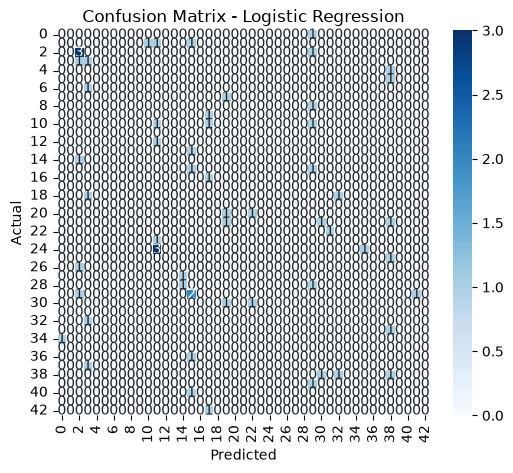

In [8]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Step 9: Train Decision Tree

Train a Decision Tree classifier and generate predictions.

In [9]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("✅ Decision Tree Model Trained Successfully!")

✅ Decision Tree Model Trained Successfully!


## Step 10: Evaluate Decision Tree

Evaluate the Decision Tree model and compare predicted values with actual values.

In [10]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_dt, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_dt, average="weighted"))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.1
Precision: 0.2
Recall   : 0.1
F1 Score : 0.1238888888888889

Confusion Matrix
[[1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Classification Report
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         0
           6       1.00      0.25      0.40         4
           7       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         0
          19       0.00      0.00      0.00         1
          20       1.00      1.00      1.00         1
          22       0.00      0.00      0.00         0
          24       0.00      0.00      0.00         1
       

## Step 11: Train Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


## Step 12: Evaluate Random Forest

Evaluate the Random Forest model using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Classification Report.

In [12]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_rf, average="weighted"))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.1
Precision: 0.09722222222222222
Recall   : 0.1
F1 Score : 0.09587301587301587

Confusion Matrix
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]]

Classification Report
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         3
           6       0.67      0.50      0.57         4
           7       0.00      0.00      0.00         0
          13       0.25      0.50      0.33         2
          19       0.00      0.00      0.00         1
          20       0.00      0.00      0.00         1
          22       0.00      0.00      0.00         0
          24       0.00      0.00      0.00         1
          26       0.00      0.00      0.00         1
          27       0.00      0.00      0.00 

## Step 13: Feature Importance

Display the importance of each feature in the Random Forest model.

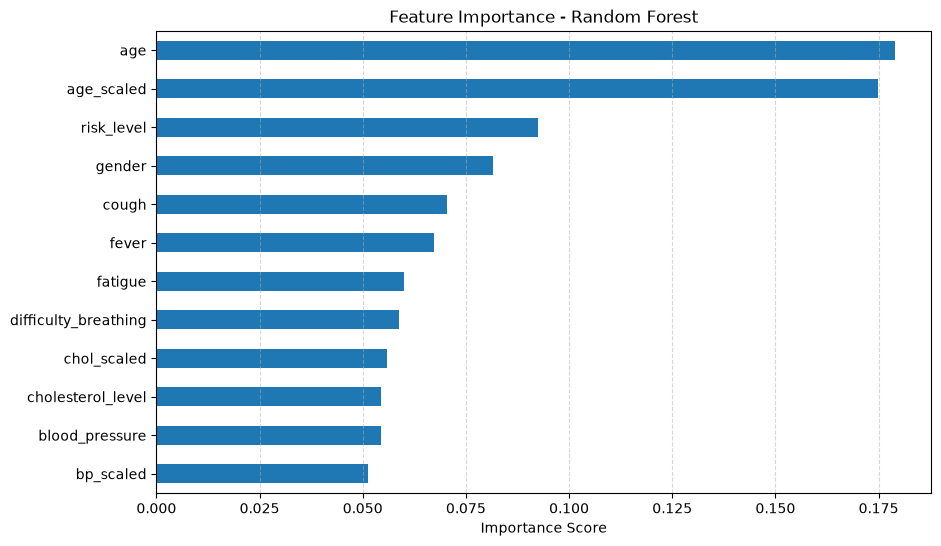

In [13]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10,6))

importance.plot(kind="barh")

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

## Step 14: Save the Trained Model

Save the trained Random Forest model so it can be used later for disease prediction.

In [14]:
import os
import joblib

os.makedirs("../../models", exist_ok=True)

joblib.dump(rf_model, "../../models/random_forest_model.pkl")

print("✅ Random Forest Model Saved Successfully!")

# Verify the model features
print(rf_model.feature_names_in_)

✅ Random Forest Model Saved Successfully!
['fever' 'cough' 'fatigue' 'difficulty_breathing' 'age' 'gender'
 'blood_pressure' 'cholesterol_level' 'age_scaled' 'bp_scaled'
 'chol_scaled' 'risk_level']


## Step 15: Train K-Nearest Neighbors (KNN)

Train a KNN classifier and generate predictions for the test dataset.

In [15]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("✅ KNN Model Trained Successfully!")

✅ KNN Model Trained Successfully!


## Step 16: Train Support Vector Machine (SVM)

Train a Support Vector Machine model and generate predictions.

In [16]:
svm_model = SVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("✅ SVM Model Trained Successfully!")

✅ SVM Model Trained Successfully!


## Step 17: Train Naive Bayes

Train a Gaussian Naive Bayes model and generate predictions.

In [17]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("✅ Naive Bayes Model Trained Successfully!")

✅ Naive Bayes Model Trained Successfully!


## Step 18: Model Performance Comparison

Compare all machine learning models based on their accuracy.

                 Model  Accuracy
0  Logistic Regression  0.100000
1        Decision Tree  0.100000
2        Random Forest  0.100000
4                  SVM  0.083333
5          Naive Bayes  0.083333
3                  KNN  0.050000


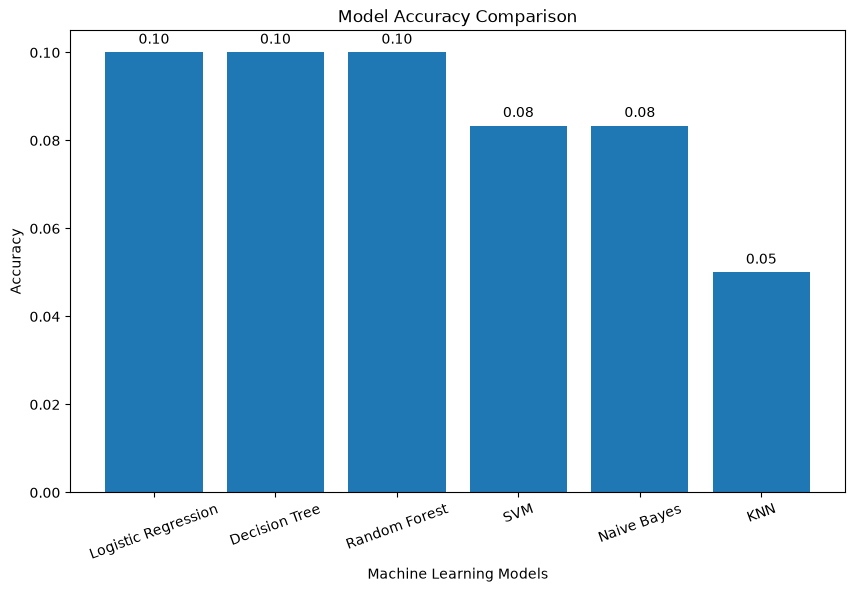


🏆 Best Model
Model       Logistic Regression
Accuracy                    0.1
Name: 0, dtype: object


In [18]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_nb)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

print(results)

plt.figure(figsize=(10,6))
plt.bar(results["Model"], results["Accuracy"])

plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Models")
plt.title("Model Accuracy Comparison")

for index, value in enumerate(results["Accuracy"]):
    plt.text(index, value + 0.002, f"{value:.2f}", ha="center")

plt.show()

print("\n🏆 Best Model")
print(results.iloc[0])